## Xử lí dữ liệu


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# =======================================================
# PHẦN 1: TIỀN XỬ LÝ DỮ LIỆU
# =======================================================
# BƯỚC 1: ĐỌC VÀ MÔ TẢ DỮ LIỆU
# Đọc file CSV
df = pd.read_csv('E:\\smartphones_data.csv.csv')

# Kiểm tra kích thước và liệt kê các cột
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())

# Kiểm tra kiểu dữ liệu
print("\nThông tin kiểu dữ liệu:")
print(df.info())

Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   str    
 1   Name                  3260 non-null   str    
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   str    
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null   str    
 

In [4]:
# BƯỚC 2: PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU LỖI
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())


Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [5]:
# Xử lý giá trị thiếu (missing values)
# điền median (trung vị) cho các cột số và mode (yếu tố xuất hiện nhiều nhất) cho cột phân loại

numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Xử lý giá trị không hợp lệ & dị thường
# Giá RAM, storage, Battery_cap không được âm hoặc bằng 0
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]

# Số lượng camera không được bằng 0
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]

# Kích thước màn hình <= 8 inch
df = df[df['display_size(inch)'] <= 8]


# Xử lý kiểu dữ liệu các biến Categorical Yes/No -> 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Xử lý cột OS
# Gom thành 3 nhóm rõ ràng: 'android', 'ios', và 'other'
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')

In [6]:
# BƯỚC 3: CHUYỂN ĐỔI DỮ LIỆU VỀ DẠNG PHÙ HỢP

# Bỏ cột 'Name'
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

# One-Hot Encoding cho biến categorical: brand_name, processor_brand, display_types
cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Ép kiểu boolean True/False từ get_dummies về dạng 1/0 (số nguyên)
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)

In [7]:
# BƯỚC 4: CHUẨN HÓA GIÁ TRỊ
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột Numeric đầu vào, không chuẩn hóa đầu ra (Price) và các cột Binary (0/1)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

# Thực hiện chuẩn hóa Z-score: z = (x-mean)/s
df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\n Kích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())


 Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0        

## Phân tích, trực quan hóa và giảm chiều


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

# GIẢM CHIỀU BẰNG 2 PHƯƠNG PHÁP (PCA & LDA)
X = df.drop(columns=['Price'])
y = df['Price']

# Tạo y_class (phân loại giá thành 4 nhóm) để chạy thuật toán LDA
y_class = pd.qcut(df['Price'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# Giảm chiều bằng PCA (6 chiều)
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X)

# Giảm chiều bằng LDA (3 chiều)
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X, y_class)

# Xác định lượng thông tin được bảo tồn (Explained Variance)
print(f"PCA (6 chiều đầu) - % từng chiều: {pca.explained_variance_ratio_ * 100}")
print(f"PCA - Tổng thông tin giữ lại ở 6 chiều: {sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

print(f"LDA (3 chiều) - % từng chiều: {lda.explained_variance_ratio_ * 100}")
print(f"LDA - Tổng khả năng phân biệt lớp ở 3 chiều: {sum(lda.explained_variance_ratio_) * 100:.2f}%")

Kích thước dữ liệu gốc: (3259, 70)
PCA (6 chiều đầu) - % từng chiều: [40.46173384 10.52829825  7.6736999   6.02414958  4.72621812  4.2984874 ]
PCA - Tổng thông tin giữ lại ở 6 chiều: 73.71%

LDA (3 chiều) - % từng chiều: [80.99658028 16.728592    2.27482772]
LDA - Tổng khả năng phân biệt lớp ở 3 chiều: 100.00%


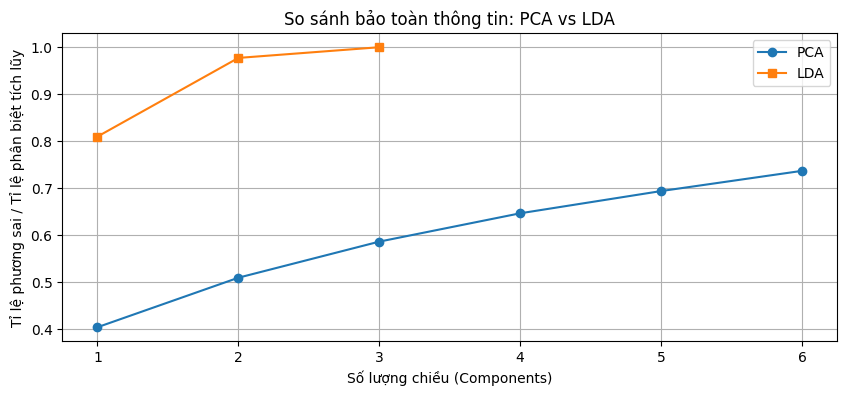

In [20]:
# Vẽ đồ thị Explained Variance
plt.figure(figsize=(10, 4))
plt.plot(range(1, 7), np.cumsum(pca.explained_variance_ratio_), marker='o', label='PCA')
plt.plot(range(1, 4), np.cumsum(lda.explained_variance_ratio_), marker='s', label='LDA')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai / Tỉ lệ phân biệt tích lũy')
plt.title('So sánh bảo toàn thông tin: PCA vs LDA')
plt.legend()
plt.grid(True)
plt.show()

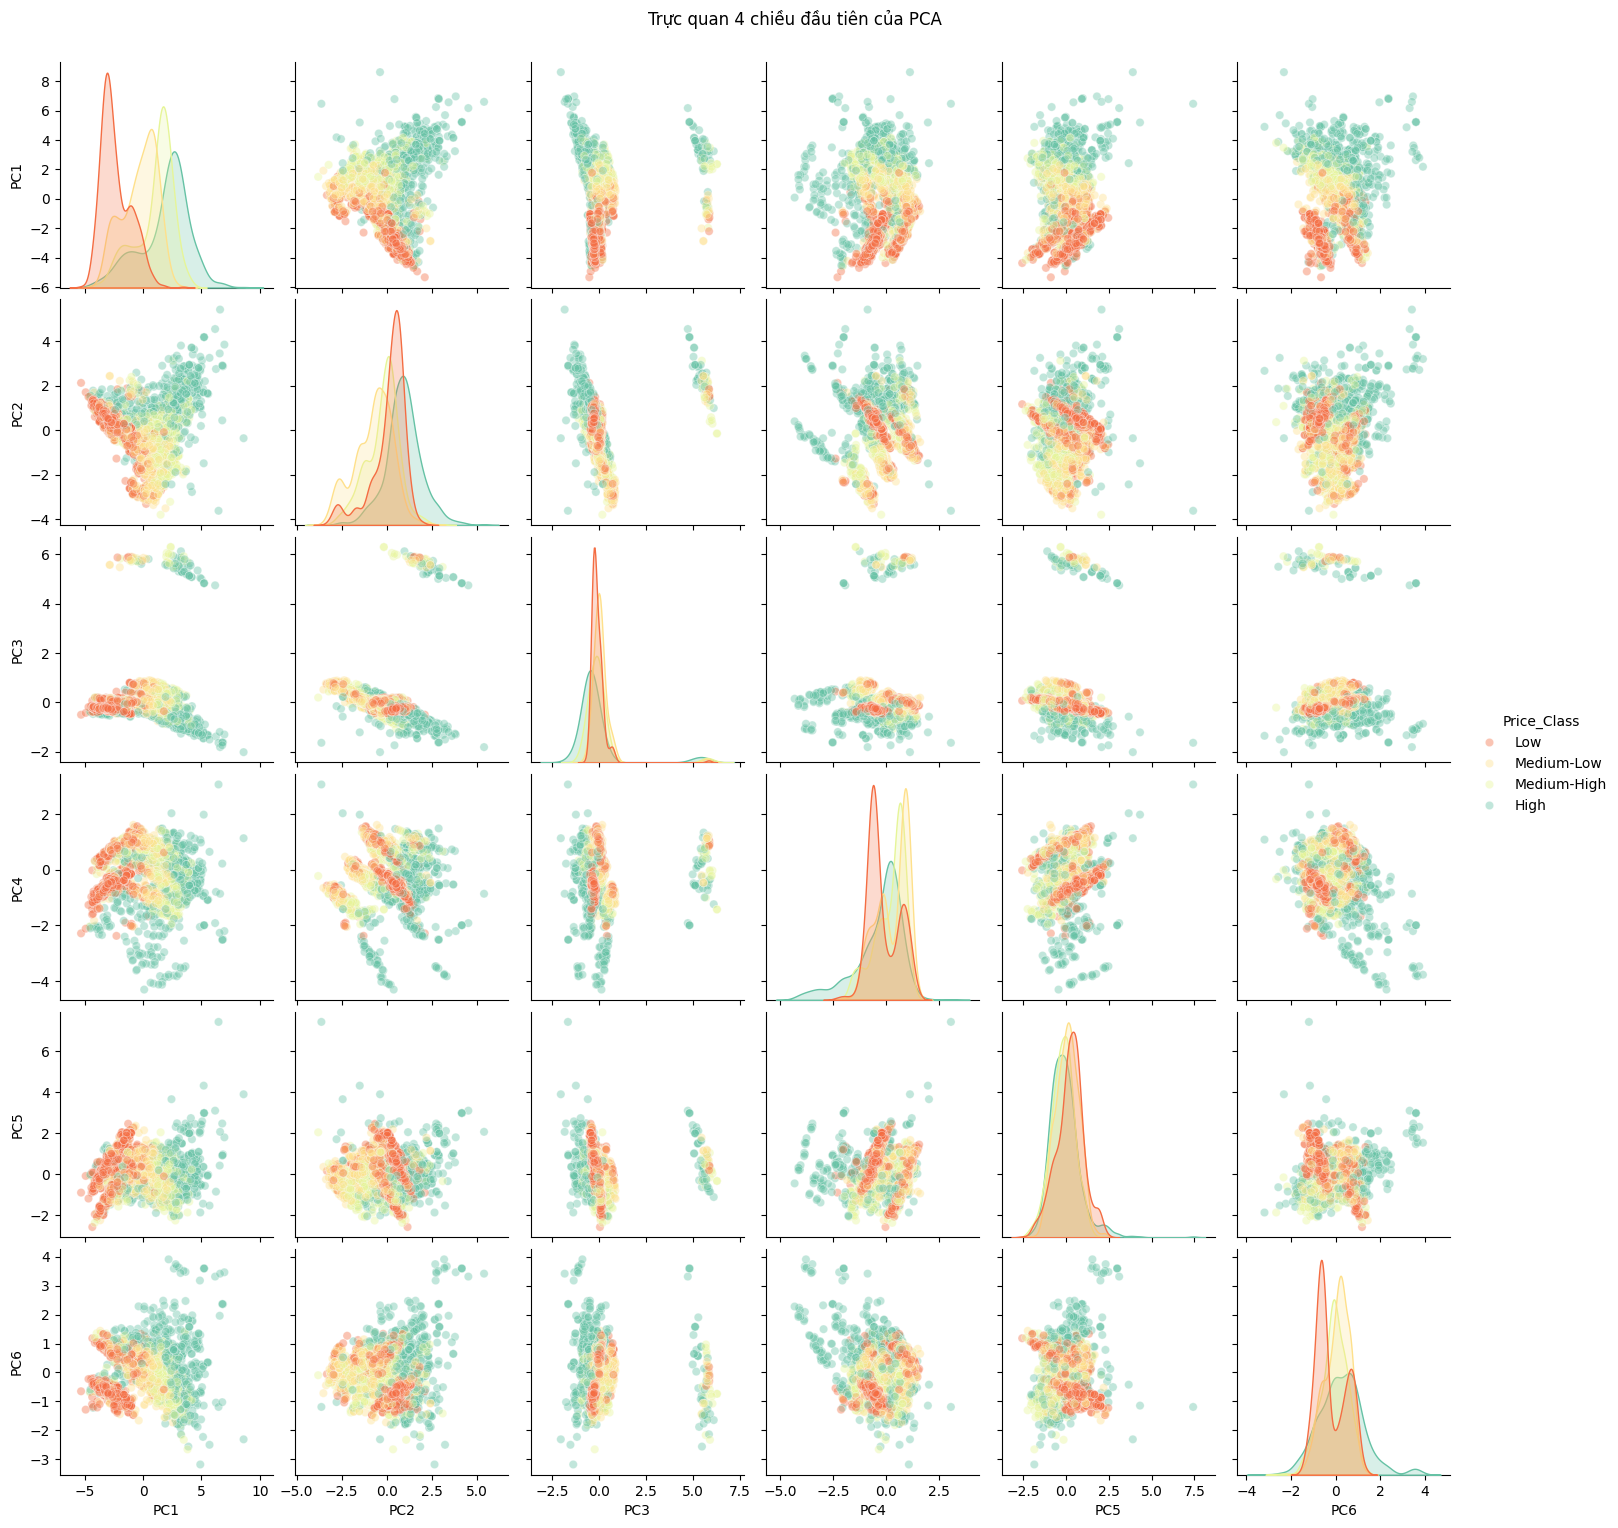

In [21]:
# TRỰC QUAN HÓA THEO 2 CẶP THÀNH PHẦN CHÍNH
# Pairplot cho PCA
df_pca = pd.DataFrame(X_pca[:, :6], columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])
df_pca['Price_Class'] = y_class.values
sns.pairplot(df_pca, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 4 chiều đầu tiên của PCA', y=1.02)
plt.show()

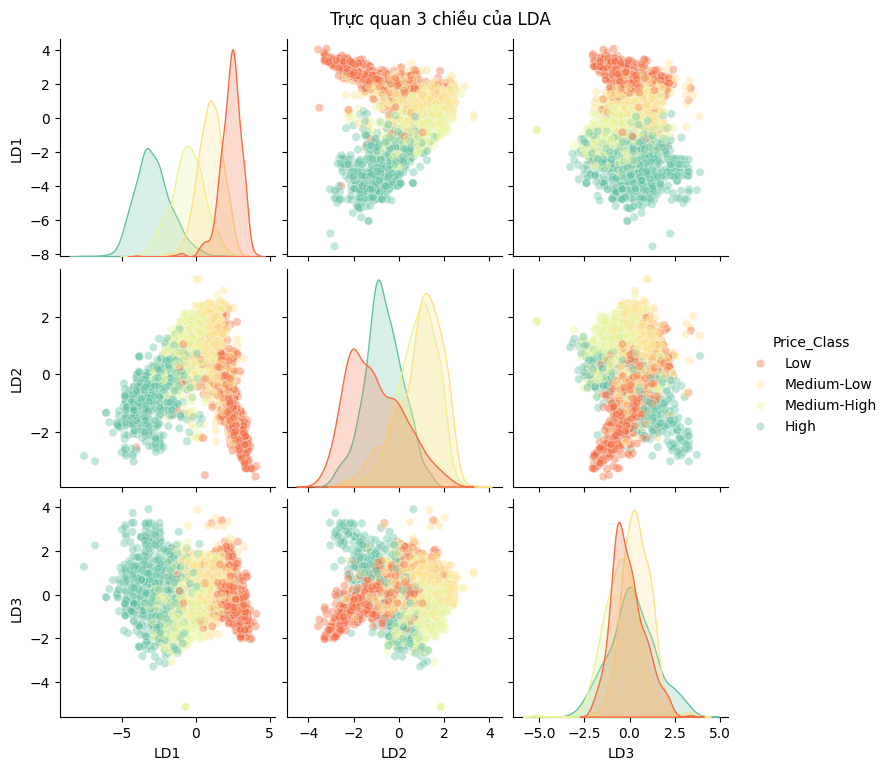

In [23]:
# Pairplot cho LDA
df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2', 'LD3'])
df_lda['Price_Class'] = y_class.values
sns.pairplot(df_lda, hue='Price_Class', diag_kind='kde', plot_kws={'alpha': 0.4}, palette='Spectral')
plt.suptitle('Trực quan 3 chiều của LDA', y=1.02)
plt.show()

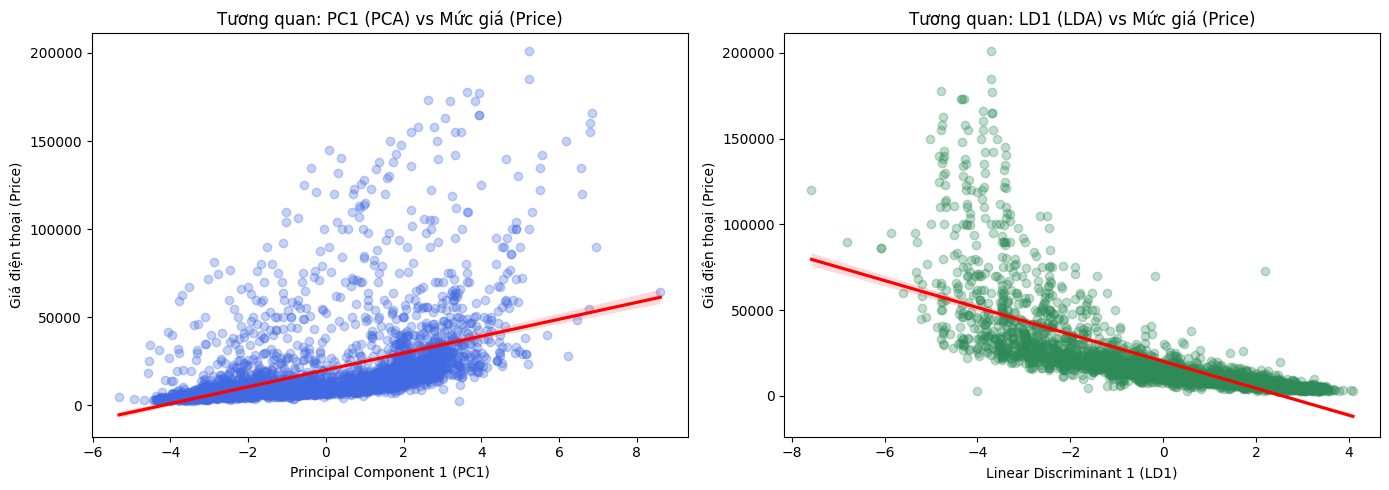

In [24]:
# MỐI QUAN HỆ CHIỀU CHÍNH VỚI ĐẦU RA (TƯƠNG QUAN TUYẾN TÍNH)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 của PCA với Price thực tế
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0], scatter_kws={'alpha':0.3, 'color': 'royalblue'}, line_kws={'color':'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('Principal Component 1 (PC1)')
axes[0].set_ylabel('Giá điện thoại (Price)')

# LD1 của LDA với Price thực tế
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1], scatter_kws={'alpha':0.3, 'color': 'seagreen'}, line_kws={'color':'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('Linear Discriminant 1 (LD1)')
axes[1].set_ylabel('Giá điện thoại (Price)')

plt.tight_layout()
plt.show()